In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_bloch_vector
from qiskit.circuit.library.standard_gates import ZGate

## III. Résolution de problèmes NP-complet : La révolution de la superposition quantique ?

### III.A. Algorithmes et complexité : définition d'un problème NP-complet

#### III.A.1) Complexité d'un algorithme

Classiquement, on classe les algorithmes selon leur complexité en temps (nombre d'opérations) ou en espace, ce qui nous permet de comparer les algorithmes selon leurs "besoins" en ressources, comme le temps de calcul ou l'espace mémoire.

Ainsi, lors de l'optimisation d'un problème, l'une des notions les plus importantes est la complexité en temps en fonction d'une quantité $n$ de données à traiter. 
Dans ce sens, on qualifiera la complexité de chaque algorithme à l'aide des notations de Landau $O$ tel que :
* $O(1)$ : le temps ne dépend pas de la taille de l’entrée
* $O(n)$ : le temps d'execution est linéaire à celui de l'entrée
* $O(n^k)$ : le temps d'execution est polynomiale (quadratique, cubique...)
* $O(2^n), O(n!)$ : le temps d'execution est exponentiel

![tab-complexite.png](attachment:tab-complexite.png)

#### III.A.2) Théorie de la complexité

Afin de pouvoir rendre compte plus généralement de la complexité d'un **problème**, souvent présenté sous la forme d'une question (contrairement à l'algorithme), il faut commencer par poser le cadre théorique de ces problèmes.

On appelle **problème de décision** une application qui associe à n'importe quelle donnée du problème (appelée une *instance*), une valeur booléenne : vrai ou faux.

*Par exemple : $3 \in \{1;3;4;7;9\} \, \rightarrow$ vrai, mais $5 \in \{1;3;4;7;9\} \, \rightarrow$ faux*

*Le problème de décision est donc "$x$ appartient-t-il à $\{1;3;4;7;9\}$ ?" et les instances sont 3 (vrai) et 5 (faux).*

Dans ce sens, on dit qu'un problème est décidable s’il existe un algorithme qui y répond de manière correcte et **en temps fini** (ie. qui décide en temps fini si l'instance vérifie le problème).

Plus précisément, la thèse de Cobham-Edmonds définie les **problèmes raisonnables** :
> *Les problèmes calculables facilement (dits problèmes raisonables) sont les problèmes calculables en **temps polynomial**.*

#### III.A.3) Les classes $P$ et $NP$

Afin de pouvoir séparer les problèmes dits raisonnables des autres, il a donc fallu les classifier en deux catégories : les problèmes $P$ et les problèmes $EXP$.

La classe $P$ correspond à l'ensemble des problèmes décidés en **temps polynomial déterministe**, tandis que la classe $EXP$ correspond à ceux décidés en un **temps exponentiel**. 

Par exemple, pour un même graphe valué $G$ et deux sommets *i* et *j*, on peut avoir deux problèmes différents en complexité : 
* Le problème d'accessibilité : "Existe-t-il un chemin de i à j ?"

$\quad\quad\rightarrow$ résolvable en $O(n^2)$ $\implies$ temps polynomial

* Le problème du voyageur de commerce : "Quel est le chemin de i à j le moins couteux ?"

$\quad\quad\rightarrow$ résolvable en $O(2^n)$ $\implies$ temps exponentiel

On a donc : $P \subsetneq  EXP$ 

Finalement, la classe $NP$ représente l'ensemble des problèmes décidés en temps polynomial **non déterministe**.

> *Remarque : $NP$ ne signifie pas “Non Polynomial” mais “Polynomial en temps Non déterministe”.*

On parle de problème non déterministe lorsqu'il faut tester l'ensemble des branches possibles avant de pouvoir se prononcer sur la réponse au problème.

Dans ce sens, afin de résoudre un problème $NP$, il faut donc vérifier pour chaque branche si celle-ci répond oui au problème, jusqu'à ce que l'on trouve celle qui réponde oui.

Pour ce faire, on utilise donc ce qu'on appelle un **vérificateur**, qui est **lié à notre problème de décision**. 

#### III.A.4) Le vérificateur polynomial

Un vérificateur prend en entrée :
* une instance $x$ du problème 
* un certificat $y$ de cette instance (la réponse au problème)

Il est défini tel que : $\quad$ le vérificateur répond oui $\iff$ l'instance $x$ du problème est vraie.

Par exemple, un vérificateur du problème du TSP serait 


In [ ]:
def verifier_TSP_decision(graph, cycle, K):

    if cycle[0] != cycle[-1]:
        return False

    unique_nodes = cycle[:-1]
    if len(unique_nodes) != len(set(unique_nodes)):
        return False

    if set(unique_nodes) != set(graph.keys()):
        return False

    cost = 0
    for u, v in zip(cycle, cycle[1:]):
        if v not in graph[u]:
            return False  # arête inexistante
        cost += graph[u][v]

    return cost <= K


En d'autres termes, la classe NP représente l'ensemble des problèmes de décision qui admettent un vérificateur polynomial. C'est-à-dire, qui admettent un programme qui est capable de vérifier que la réponse à un problème de décision est correcte.

#### III.A.5) NP-complétude
> Parmi les problèmes NP, on distingue une sous-catégorie particulièrement importante : les problèmes NP-complets, qui sont à la fois dans NP et aussi « les plus difficiles » de cette classe. Si l’on trouvait un algorithme polynomial pour l’un d’eux, tous les problèmes NP pourraient alors être résolus en temps polynomial.

Le point clé à retenir est que beaucoup de problèmes NP sont difficiles à résoudre directement : aucune méthode connue ne permet de les solutionner efficacement sur un ordinateur classique.

Ces limites de calcul constituent l’un des moteurs de l’intérêt croissant pour l’informatique quantique. En effet, un certain nombre de problèmes NP et NP-complets pourraient bénéficier d’accélérations significatives grâce à des algorithmes quantiques spécialement conçus pour exploiter les propriétés physiques de la mécanique quantique.

### III.B. Fondamentaux de l'informatique quantique

#### III.B.1) Vecteur d'état 

L'un des faits les plus connus autour de l'informatique quantique est que lorsque l'on execute un programme, l'ordinateur quantique ne nous donne pas une sortie unique, mais une **distribution de probabilité** autour de l'**ensemble des sorties possibles**. 

Ceci est dû à l'architecture même d'un ordinateur quantique. En effet, pour comprendre, relevons d'abord qu'en **informatique classique**, il n'y pas besoin de distinguer l'état de la mémoire, de ce qu'on lit dans la mémoire. Les deux apparaissent simplement comme une même suite de bits.

Mais en informatique quantique, l'ordinateur n'opère pas sur une chaine de $0$ et de $1$, mais sur ce qu'on appelle un **vecteur d'état** $\left| \varphi \right\rangle$, qui est **continu**, contrairement à la séquence de bits, et dont la mesure réelle est probabiliste.

Chaque composante $x_{i, \, \,i \,\in\, \left[ 0, \,N-1 \right]}$ de ce vecteur est un nombre complexe lié à une des $N=2^n$ sorties d'un ordinateur à $n$ qubits.

$$\begin{matrix}
\left| \varphi \right\rangle \in \mathbb{C}^N, \quad\text{ tel que} & 
\left| \varphi \right\rangle = 
\begin{bmatrix} x_0 \\ x_1 \\ x_2 \\ \vdots \\ x_{N-1} \end{bmatrix}
\begin{matrix}\overset{n \text{ qbits}}{\overbrace{\left| 0\cdots 00 \right\rangle}}
 \\ \left| 0\cdots 01 \right\rangle
 \\ \left| 0\cdots 10 \right\rangle
 \\ \vdots 
 \\ \left| 1\cdots 11 \right\rangle \\.
\end{matrix}
\end{matrix}$$

La norme au carré $|x|^2$ de chacune des composantes de ce vecteur d'état, est ainsi un réel positif qui indique la probabilité d'obtenir cette sortie lors de la mesure.

En effet puisque ce vecteur d'état est de norme $1$, la somme des normes au carré $|x|^2$ de chacune de ses composantes est aussi égale à $1$, ce qui permet de retrouver une distribution de probabilité sur toutes les sorties possibles. 

##### Remarque : Composantes complexes
> Côté physique, les composantes complexes du vecteur d'état sont dûes à la nature ondulatoire de la physique quantique, sur laquelle nous n'auront pas le temps de nous attarder dans ce papier. Simplement, on peut retenir qu'une onde est décrite par son amplitude et sa phase, ce qui demande de la décrire par une partie réelle et une partie imaginaire.
>
>Ces propriétés complexes peuvent être très utiles dans de nombreux algorithmes comme l'algorithme de Shor, mais nous pourrons nous contenter de nombres réels pour les explications qui vont suivre.

A noter que, de la même manière qu'en informatique classique, un bit n'est qu'une abstraction d'un système physique capable de toggle entre 2 états ; en informatique quantique, le vecteur d'état n'est qu'une abstraction, construite à partir de réalités physiques régies par les postulats de la mécanique quantique comme le spin d'un électron ou la polérisation d'un photon. 


---

##### Vecteur d'état à 1 seul qubit

Pour comprendre pourquoi on met la norme de chaque composante au carré pour obtenir une distribution de probabilité, il suffit de prendre l'exemple d'un vecteur d'état à deux composantes $\alpha=[x,y]$.

Ce vecteur d'état étant de norme $1$ et de dimension $2$, on peut l'imaginer confiné dans un cercle de rayon $1$, tel que :

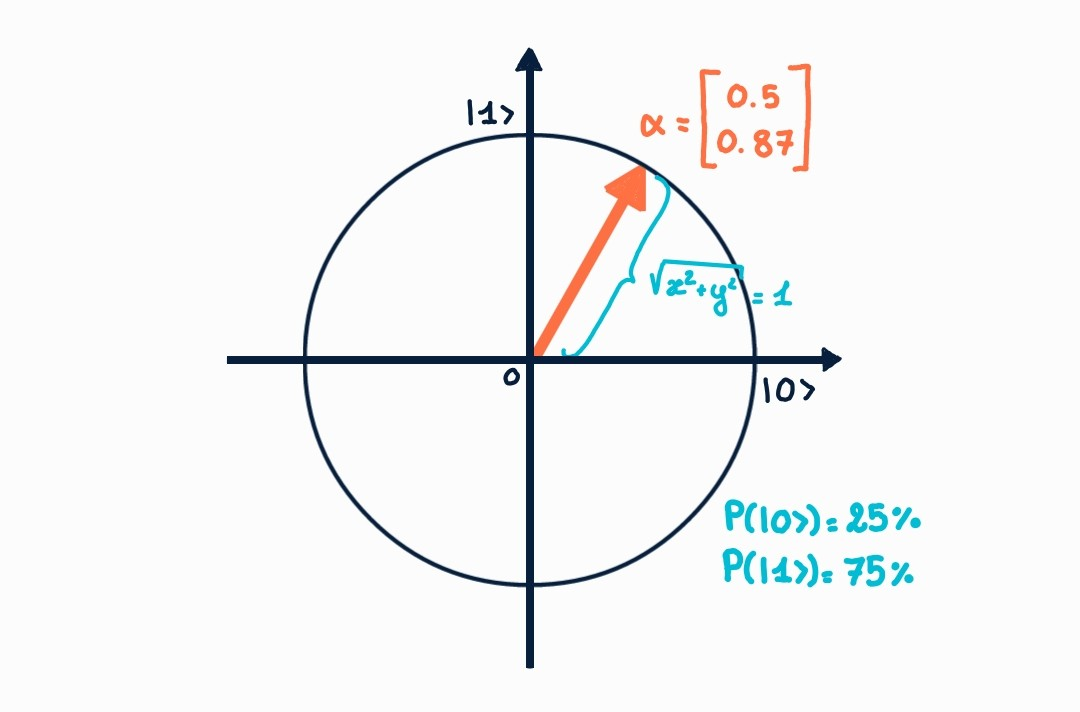

Ses composantes vérifient donc : $x^2+y^2=|\alpha|^2=1$, puisque le vecteur d'état est de norme $1$.

Pour $\alpha=[0.5,0.87]$, par exemple, on obtient donc la distribution de probabilité sur les 2 sorties possibles : $$\left| 0 \right\rangle \rightarrow x^2=(0.5)^2=25\% \quad\text{ et } \quad \left| 1 \right\rangle \rightarrow y^2=(0.87)^2=75\%$$

*A noter que l'on préfèrera noter le vecteur d'état explicitement comme la somme pondérée de ses différentes composantes : $\alpha=0.5\left| 0 \right\rangle+0.87\left| 1 \right\rangle$, une convention ici très physicienne.*

##### Généralisation à n qubit

De la même manière, n'importe quel vecteur d'état à $N$ composantes vérifie, en vertu de sa norme : $\sum_{i=1}^{N}x_i^2=1$. 

C'est-à-dire que la norme au carré de chacune de ses composantes forment une distribution de probabilités sur les $2^n$ sorties possibles. Et chaque sortie possible correspond à une des $2^n$ directions possibles dans l'hypersphère de rayon $1$ et de dimension $2^n$.


#### III.B.2) Opérations sur un vecteur d'état

Dès lors que l'on a défini le vecteur d'état manipulé par l'ordinateur dans le cadre d'un programme informatique, on va pouvoir se pencher sur le fonctionnement de ces programmes.

En informatique classique, n'importe quelle fonction peut se comprendre comme une imbrication plus ou moins compliquées de différentes ***portes logiques*** comme AND, OR et NOT.

En informatique quantique, similairement, on utilise ce que l'on appelle des ***portes quantique***, qui représentent des **opérations linéaires** sur le vecteur d'état. 

Chaque porte quantique agit donc sur l'ensemble des $N=2^n$ sorties possibles d'un ordinateur à $n$ qubits, en conservant la norme $1$ du vecteur d'état, afin de garder une distribution de probabilité des différentes sorties.

Dans ce sens, on peut représenter les portes quantiques par des matrices $U\in\mathscr{M}_{N,N}(\mathbb{C})$ dites **unitaires** ($U^{-1}=U^\dagger$), c'est-à-dire visuellement, qu'elles ne font que tourner ou réfléchir le vecteur d'état. 

#### Exemple de portes quantiques : les matrices de Pauli

Les matrices de Pauli sont des portes quantiques typiques qui permettent de réaliser des opérations particulières sur un qubit. 

On compte trois matrices de Pauli : $X$, $Y$, et $Z$. 

Chacune permette de modifier l'orientation du vecteur d'état selon une direction $x$, $y$, ou $z$ dans l'espace. Pour comprendre leur fonctionnement on utilisera donc la **sphère de Bloch**.


#### Comprendre les portes quantiques : La porte $X=\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ 

> $$\begin{matrix}\left| \varphi \right\rangle = \varphi_0 \left| 0 \right\rangle + \varphi_1 \left| 1 \right\rangle & \implies & \left| \varphi' \right\rangle = X\left| \varphi \right\rangle = \varphi_1 \left| 0 \right\rangle + \varphi_0 \left| 1 \right\rangle\end{matrix}$$

La porte X peut-être considérée comme l’équivalent quantique de la porte NOT en informatique classique : elle inverse les probabilités de chaque sortie.

##### Exemple sur la phère de Bloch

Typiquement, un vecteur d'état qui pointe vers le $\left| 0 \right\rangle$ (au Nord), pointera vers le $\left| 1 \right\rangle$ (au Sud) après application de la porte $X$ et vice versa.

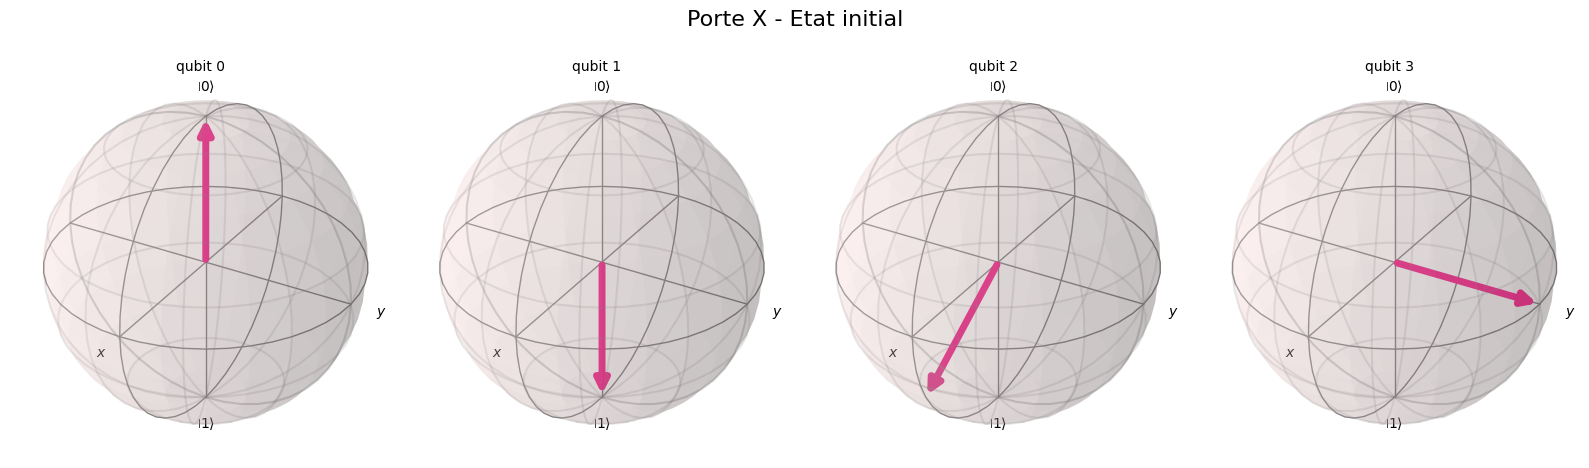

In [2]:
qc = QuantumCircuit(4)

qc.initialize([1, 0], 0) # optionnel : sur qiskit le vecteur est initialisé à 0
qc.initialize([0, 1], 1)
qc.initialize([1/2, np.sqrt(3)/2], 2)
# qc.initialize([1/np.sqrt(2)*1j, 1/np.sqrt(2)*1j], 3) marche pas ?
qc.h(3)
qc.rz(np.pi/2,3)
state = Statevector(qc)
plot_bloch_multivector(state, title = "Porte X - Etat initial")

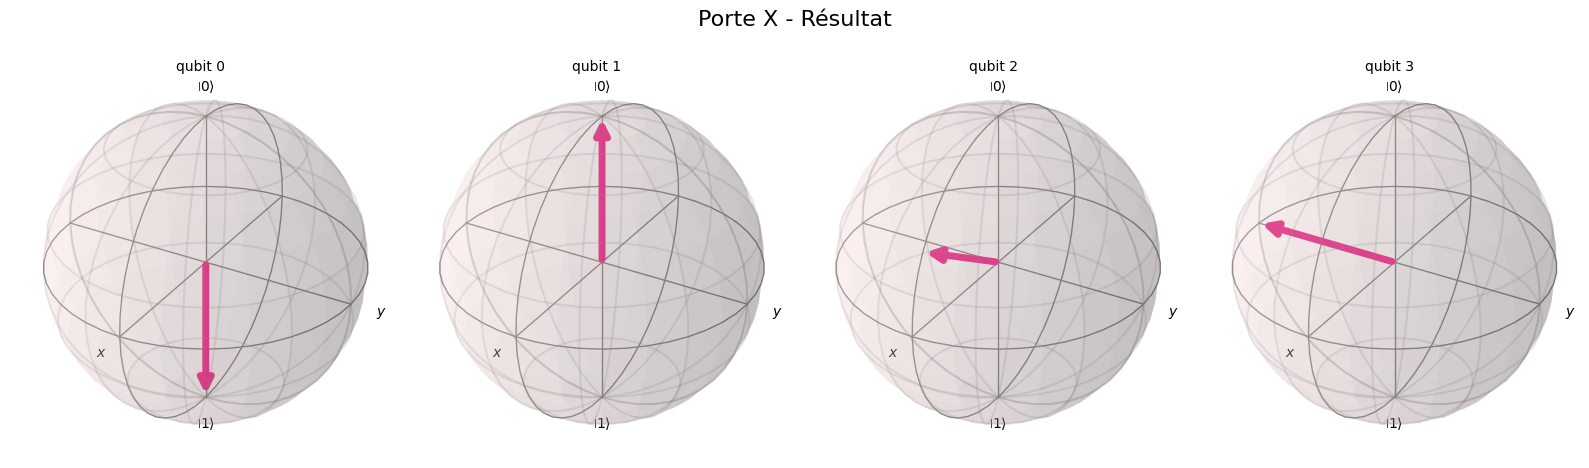

In [3]:
for i in range (4): 
    qc.x(i)

state = Statevector(qc)
plot_bloch_multivector(state, title = "Porte X - Résultat")

On comprend donc que la porte $X$ fait tourner les vecteurs de $180°$ autour de l'axe $x$. 

Ainsi, les seuls vecteurs qui ne sont pas concernés sont les vecteurs colinéaires à l'axe $x$ : les vecteurs propres de la matrice $X$

$$\begin{matrix}
\left| + \right\rangle=\frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 1\end{bmatrix} = \frac{\left| 0 \right\rangle + \left| 1 \right\rangle}{\sqrt{2}}
& \text{et} & 
\left| - \right\rangle=\frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ -1\end{bmatrix} = \frac{\left| 0 \right\rangle - \left| 1 \right\rangle}{\sqrt{2}}
\end{matrix}$$

Où $\left| + \right\rangle$ est le vecteur propre associé à la valeur propre $1$ : $\quad X\left| + \right\rangle=+\left| + \right\rangle$

et $\left| - \right\rangle$ est le vecteur propre associé à la valeur propre $-1$ : $\quad X\left| - \right\rangle=-\left| - \right\rangle$

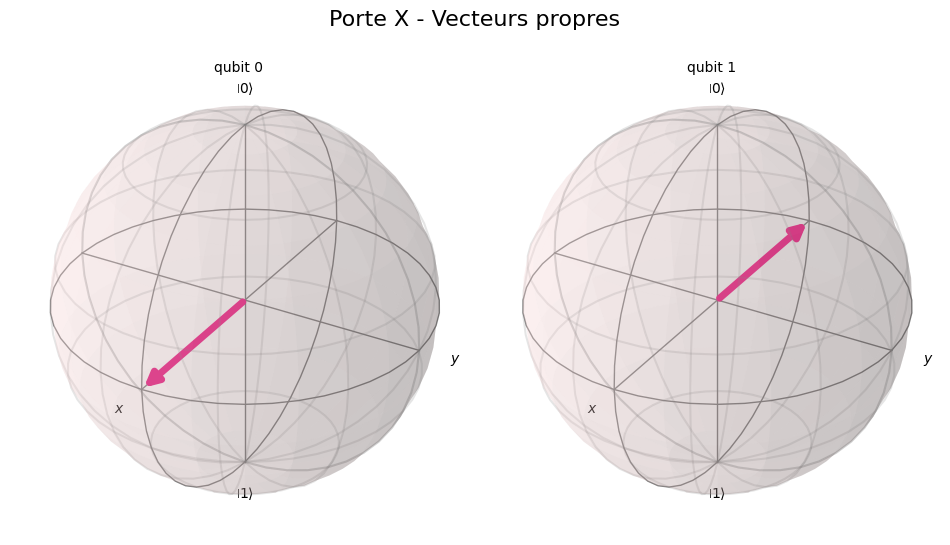

In [4]:
qc = QuantumCircuit(2)

a = 1/np.sqrt(2)
qc.initialize([a, a], 0)
qc.initialize([a, -a], 1)
state = Statevector(qc)
plot_bloch_multivector(state, title = "Porte X - Vecteurs propres")

##### Les portes $Y=\begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$ et $Z=\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$

> $$\begin{matrix}Y : & \left| \varphi \right\rangle = \varphi_0 \left| 0 \right\rangle + \varphi_1 \left| 1 \right\rangle & \implies & \left| \varphi' \right\rangle = Y\left| \varphi \right\rangle = -i\varphi_1 \left| 0 \right\rangle + i\varphi_0 \left| 1 \right\rangle\end{matrix}$$
>
> $$\begin{matrix}Z : & \left| \varphi \right\rangle = \varphi_0 \left| 0 \right\rangle + \varphi_1 \left| 1 \right\rangle & \implies & \left| \varphi' \right\rangle = Z\left| \varphi \right\rangle = \varphi_0 \left| 0 \right\rangle - \varphi_1 \left| 1 \right\rangle\end{matrix}$$

Les portes $Y$ et $Z$, similairement, font tourner le vecteur de $180°$ autour de l'axe $y$ ou $z$.

Ainsi, leurs vecteurs propres sont aussi colinéaires à ce même axe et leurs valeurs propres sont aussi $-1$ et $1$ (puisqu'une porte quantique ne change pas la norme d'un vecteur).

La porte $Y$ introduit des composantes complexes qui ne nous serons pas utiles pour l'algorithme de Grover, nous ne nous attarderons donc pas plus dessus.

La porte $Z$ cependant est utile dans de nombreux programmes quantiques où l'on souhaite "marquer" un état. En effet, de par sa rotation autour de l'axe $z$, elle ne modifie pas les probabilités de chaque sortie. Elle amène simplement le vecteur d'état dans un autre cadran en inversant le signe de la deuxième composante.

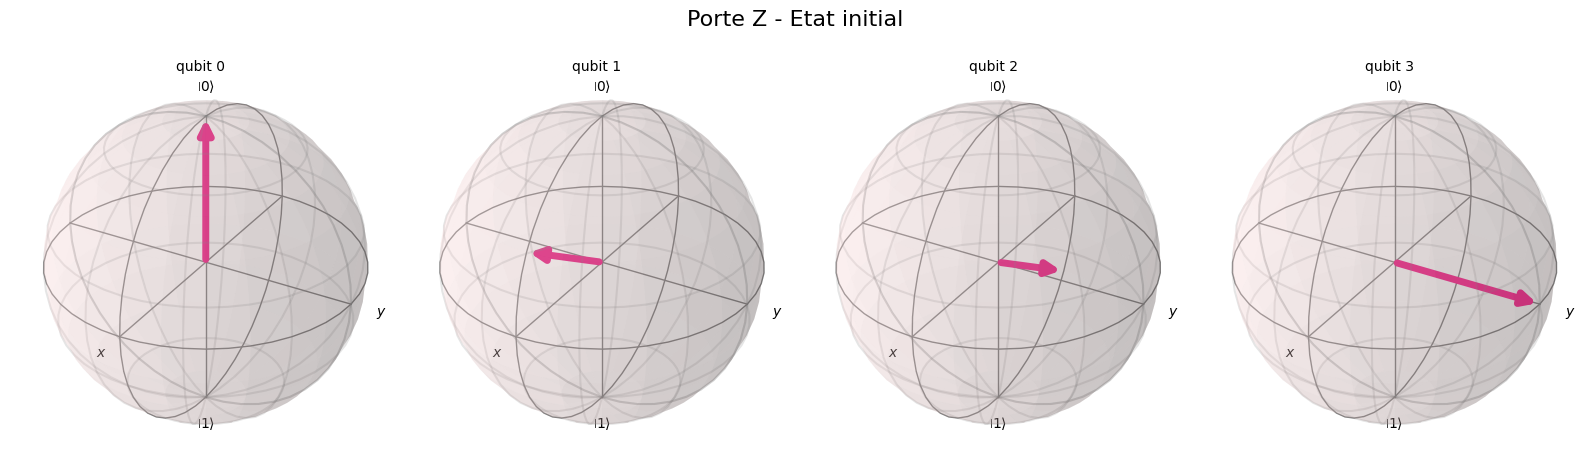

In [17]:
qc = QuantumCircuit(4)

qc.initialize([1, 0], 0) # optionnel : sur qiskit le vecteur est initialisé à 0
qc.initialize([np.sqrt(3)/2, 1/2], 1)
qc.initialize([1/2, -np.sqrt(3)/2], 2)
# qc.initialize([1/np.sqrt(2)*1j, 1/np.sqrt(2)*1j], 3) marche pas ?
qc.h(3)
qc.rz(np.pi/2,3)
state = Statevector(qc)
plot_bloch_multivector(state, title = "Porte Z - Etat initial")

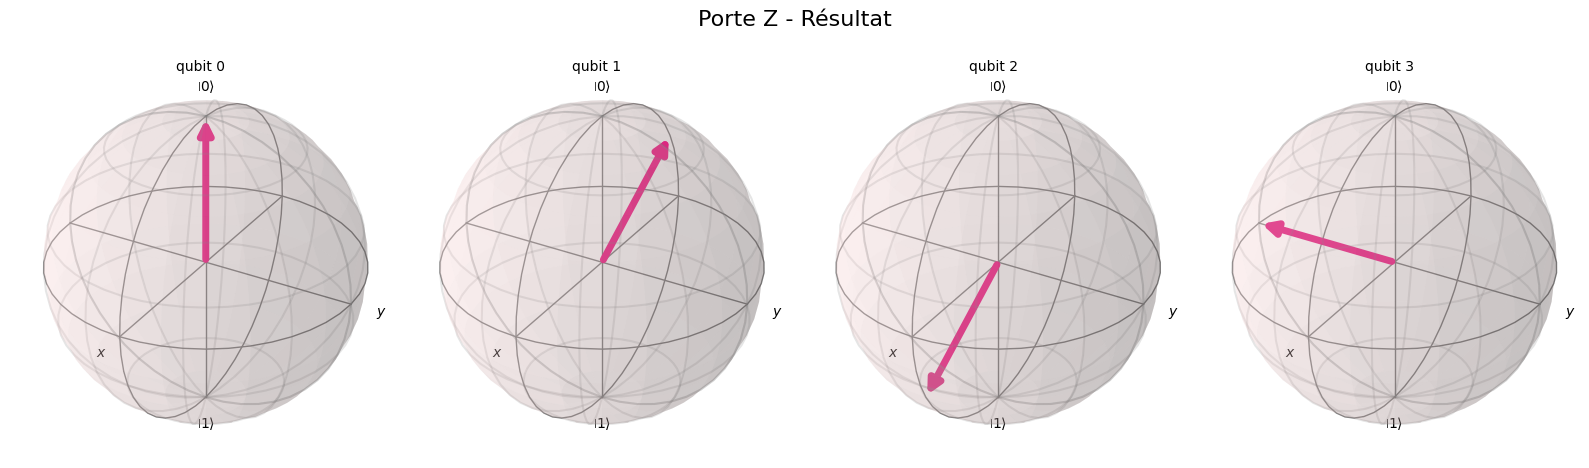

In [18]:
for i in range (4): 
    qc.z(i)

state = Statevector(qc)
plot_bloch_multivector(state, title = "Porte Z - Résultat")

##### La superposition : Hadamard gate

Pour l'instant, nous ne travaillons qu'avec un seul qubit, une information bien primaire pour être complètement exploitée. 

Dans le cadre des problèmes $NP$ par exemple, on entend souvent dire qu'un ordinateur quantique réussit à traiter les $N$ sorties **en même temps** pour effectuer ses calculs.

Pour ce faire, il doit mettre en **superposition** l'ensemble des sorties possibles. C'est-à-dire, qu'il faire en sorte qu'à l'initialisation chaque sortie ait la même probabilité $\frac{1}{N}=\left( \frac{1}{\sqrt{N}} \right)^2$ d'être mesurée.

C'est-à-dire, avoir pour vecteur d'état initial : $\left| \varphi_\text{init} \right\rangle = \frac{1}{\sqrt{N}}\left[ 1; 1; \cdots ; 1 \right]^T$.

La porte qui permet de superposer chacun des $n$ qubits de sorte à ce que les $N=2^n$ sorties soient équiprobables s'appelle la **porte Hadamard**. Elle est définie par : 
$$H=\frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

Telle que, $ \quad \varphi'=H\varphi= \frac{1}{\sqrt{2}} \begin{bmatrix}1 & 1 \\ 1 & -1 \end{bmatrix}\begin{bmatrix} \varphi_0 \\ \varphi_1 \end{bmatrix} = \frac{1}{\sqrt{2}}\begin{bmatrix} \varphi_0 + \varphi_1 \\ \varphi_0 - \varphi_1 \end{bmatrix}$

Dans ce sens, elle prend le vecteur d'état associé à un qubit et calcule un nouveau vecteur pour lequel la première composante est la "moyenne" des deux composantes originales, et la deuxième composante est la symétrie de la première composantes par l'axe des abscisses. 

Tout particulièrement, elle permet d'obtenir les vecteurs propres de la matrice $X$ avec : 
$$\begin{matrix}
H\left| 0 \right\rangle=\left| + \right\rangle & \text{et} & 
H\left| 1 \right\rangle=\left| - \right\rangle
\end{matrix}$$

##### Exemple sur la sphère de Bloch

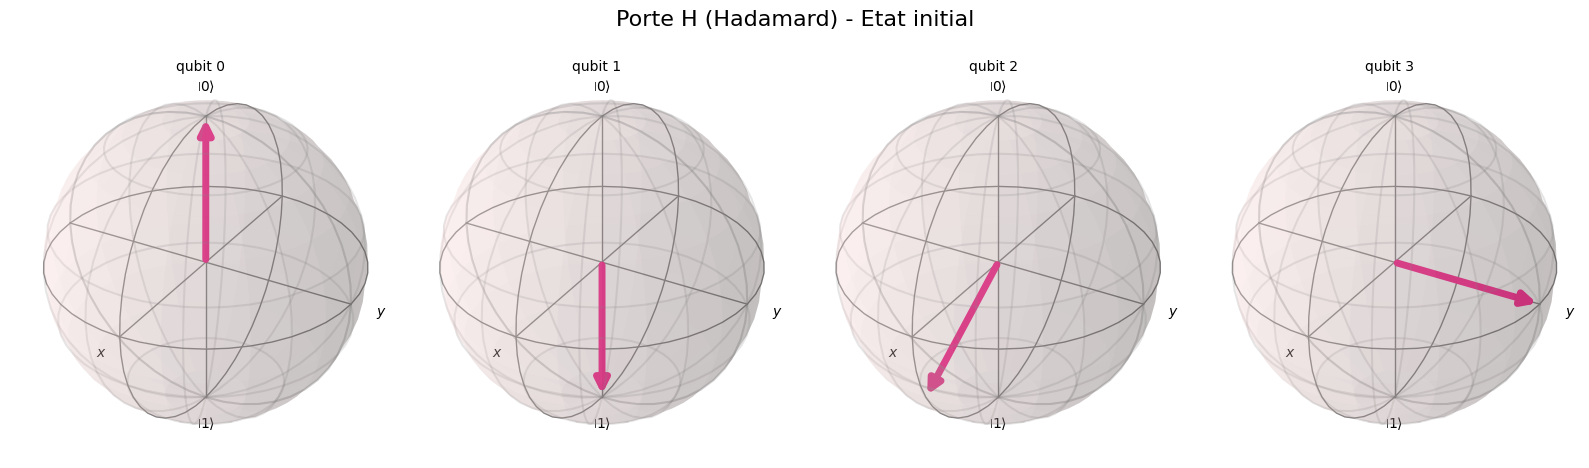

In [5]:
qc = QuantumCircuit(4)

qc.initialize([1, 0], 0) # optionnel : sur qiskit le vecteur est initialisé à 0
qc.initialize([0, 1], 1)
qc.initialize([1/2, np.sqrt(3)/2], 2)
# qc.initialize([1/np.sqrt(2)*1j, 1/np.sqrt(2)*1j], 3) marche pas ?
qc.h(3)
qc.rz(np.pi/2,3)
state = Statevector(qc)
plot_bloch_multivector(state, title = "Porte H (Hadamard) - Etat initial")

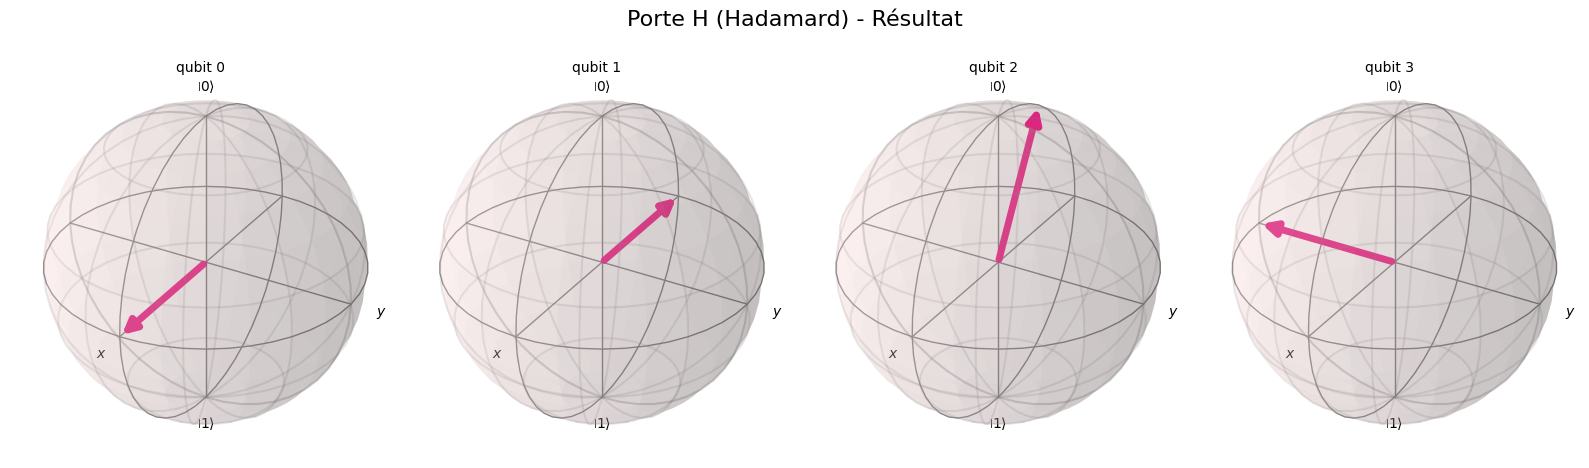

In [6]:
for i in range (4): 
    qc.h(i)

state = Statevector(qc)
plot_bloch_multivector(state, title = "Porte H (Hadamard) - Résultat")

Dans ce sens, plus le vecteur d'état suivra une direction horizontale, plus il sera poussé vers l'une ou l'autre des directions de base (verticale), et inversement, plus le vecteur d'état suivra une direction des directions de base, plus il sera poussé vers une direction horizontale.

##### Remarque
> *A noter que cette porte est dite autoadjointe, dans le sens où, si on applique cette porte une 2e fois, on revient à l'état initial : $\forall \left| \varphi \right\rangle,\, HH\left| \varphi \right\rangle=I\left| \varphi \right\rangle=\left| \varphi \right\rangle$*